# Power Infrastructure Feature Experiments — Monthly Wildfire Ignition Model

**Purpose:** Systematically evaluate how different combinations of power
infrastructure density features affect wildfire ignition prediction skill.
Five feature-set experiments are crossed with five training-window lengths
(4–8 water years), yielding **25 model configurations**. Each configuration
is evaluated with a rolling water-year scheme that predicts years 2001–2020.

**Experimental design:**

| ID | Label | Extra features added to base |
|----|-------|------------------------------|
| E1 | `line` | `trans_line_density` |
| E2 | `line+minor` | `trans_line_density`, `minor_line_density` |
| E3 | `pole+tower` | `pole_density`, `tower_density` |
| E4 | `line+minor+pole+tower` | all four above |
| E5 | `all_power` | all four + `transformer_density` |

For each of the 25 combinations the notebook produces:

- **AUC-ROC** time series (per water year)
- **AUC-PRG** time series (Precision-Recall-Gain; Flach & Kull 2015)
- **Spearman ρ** on deseasonalised ignition anomalies (value only)

**Model:** XGBoost (`tree_method='hist'`) → sigmoid probability calibration
on a held-out 10 % set (`CalibratedClassifierCV`).

> **Data lineage:** Feature-preparation pipeline in `E:\zcao\CA_Wildfire`
> (20 notebooks, stages 00–03). Final monthly dataset version:
> `Monthly_03152026_calibration/`.

## 0. Configuration

All editable paths and experiment parameters live in this single cell.

In [1]:
import os

# ======================== PATHS ========================
# Source data (read-only, from feature-preparation pipeline)
DATA_ROOT    = r"E:\zcao\CA_Wildfire"
DATA_VERSION = "Monthly_03152026_calibration"
DATA_DIR     = os.path.join(DATA_ROOT, "Clean_Data", "Model_Data",
                            "Evaluation", "Features_w_Label", DATA_VERSION)

# Experiment outputs (new project directory)
PROJECT_ROOT = r"E:\zcao\Ignition - ML Modeling"
MODEL_DIR    = os.path.join(PROJECT_ROOT, "Models")
PRED_DIR     = os.path.join(PROJECT_ROOT, "Predictions")
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "Results")
LOG_DIR      = os.path.join(PROJECT_ROOT, "Logs")

for d in [MODEL_DIR, PRED_DIR, RESULTS_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# =================== EXPERIMENT GRID ===================
TRAIN_LENGTHS  = [4, 5, 6, 7, 8]
PREDICT_YEARS  = list(range(2001, 2021))
RANDOM_STATE   = 42
LABEL_COL      = "IS_FIRE"

# ======================== QA ==========================
print(f"Data dir    : {DATA_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"  [{'OK' if os.path.isdir(DATA_DIR) else 'MISSING'}] DATA_DIR")

Data dir    : E:\zcao\CA_Wildfire\Clean_Data\Model_Data\Evaluation\Features_w_Label\Monthly_03152026_calibration
Project root: E:\zcao\Ignition - ML Modeling
  [OK] DATA_DIR


## 1. Environment

In [2]:
import sys, gc, warnings, pickle, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             precision_recall_curve, auc)
from scipy.stats import spearmanr, rankdata

gc.collect()
print(f"Python  : {sys.version.split('|')[0].strip()}")
print(f"pandas  : {pd.__version__}")
print(f"xgboost : {xgb.__version__}")

Python  : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas  : 2.2.2
xgboost : 2.1.4


## 2. Load & Prepare Data

Load the 10 % calibration and 90 % non-calibration splits produced by
`03_04_Prepare_Monthly_Model_Data_Calibration`. Rename the wind-direction
octant day-count columns (suffix `_freq`) so they do not collide with the
one-hot dummies, then encode `veg_group` and `wind_direction_category`.

In [3]:
# --- Load splits ---
cali_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_calibration.parquet"))
mod_data  = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_non_calibration.parquet"))

# Rename octant day-count columns to avoid clash with one-hot dummies
octant_dirs = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
rename_map  = {f"wind_direction_category_{d}": f"wind_direction_category_{d}_freq"
               for d in octant_dirs}
cali_data = cali_data.rename(columns=rename_map)
mod_data  = mod_data.rename(columns=rename_map)

# --- One-hot encode categoricals ---
cat_cols  = ["veg_group", "wind_direction_category"]
cali_data = pd.get_dummies(cali_data, columns=cat_cols)
mod_data  = pd.get_dummies(mod_data,  columns=cat_cols)

# --- Derive month column (needed for Spearman anomaly calculation) ---
if "month" not in mod_data.columns:
    mod_data["month"]  = mod_data["year_month"].dt.month
    cali_data["month"] = cali_data["year_month"].dt.month

# --- Fix calibration window (match original pipeline) ---
cali_fixed = cali_data[cali_data["water_year"] >= 2001].copy()

# --- Earliest available training month ---
min_ym_global = mod_data["year_month"].min().strftime("%Y-%m")

print(f"Non-calibration : {mod_data.shape}  fire rate: {mod_data[LABEL_COL].mean():.4f}")
print(f"Calibration     : {cali_fixed.shape}  fire rate: {cali_fixed[LABEL_COL].mean():.4f}")
print(f"Earliest year_month: {min_ym_global}")
print(f"Columns after encoding: {mod_data.shape[1]}")

Non-calibration : (3396205, 81)  fire rate: 0.0194
Calibration     : (282422, 81)  fire rate: 0.0185
Earliest year_month: 1994-01
Columns after encoding: 81


## 3. Define Features & Experiments

**Base features** include weather, wind direction, vegetation, terrain,
road density, LAI, and the previous-fire lag — everything *except* power
infrastructure density variables. Each experiment adds a specific
combination of OpenStreetMap power features on top of this base.

In [4]:
# ======================== BASE FEATURES ========================
BASE_FEATURES = [
    # Weather (monthly means)
    "dead_fuel_moisture_1000hr", "dead_fuel_moisture_100hr",
    "max_air_temperature", "min_air_temperature",
    "max_relative_humidity", "min_relative_humidity",
    "precipitation_amount", "specific_humidity",
    "surface_downwelling_shortwave_flux_in_air",
    "wind_speed", "SWE",
    # Wind direction — mode one-hot (8 octants)
    "wind_direction_category_N",  "wind_direction_category_NE",
    "wind_direction_category_E",  "wind_direction_category_SE",
    "wind_direction_category_S",  "wind_direction_category_SW",
    "wind_direction_category_W",  "wind_direction_category_NW",
    # Vegetation — one-hot (6 groups)
    "veg_group_Chaparral", "veg_group_Conifer Alpine",
    "veg_group_Conifer Forest", "veg_group_Grassland",
    "veg_group_Oak Woodland", "veg_group_Shrub",
    # Continuous
    "LAI", "slope_max", "slope_avg",
    "road_density_km_km2",
    "prev_fire",
]

# =================== EXPERIMENT DEFINITIONS ===================
EXPERIMENTS = {
    "E1_line":                  ["trans_line_density"],
    "E2_line_minor":            ["trans_line_density", "minor_line_density"],
    "E3_pole_tower":            ["pole_density", "tower_density"],
    "E4_line_minor_pole_tower": ["trans_line_density", "minor_line_density",
                                 "pole_density", "tower_density"],
    "E5_all_power":             ["trans_line_density", "minor_line_density",
                                 "pole_density", "tower_density",
                                 "transformer_density"],
}

# --- Validate all features exist in the data ---
all_extra = set(f for fs in EXPERIMENTS.values() for f in fs)
missing = [f for f in list(BASE_FEATURES) + list(all_extra)
           if f not in mod_data.columns]
if missing:
    print(f"WARNING — columns not found in data: {missing}")
else:
    print(f"Base features : {len(BASE_FEATURES)}")
    print(f"Experiments   : {len(EXPERIMENTS)}")
    print(f"Train lengths : {TRAIN_LENGTHS}")
    print(f"Total runs    : {len(EXPERIMENTS) * len(TRAIN_LENGTHS)}")

Base features : 30
Experiments   : 5
Train lengths : [4, 5, 6, 7, 8]
Total runs    : 25


## 4. Helper Functions

| Function | Purpose |
|----------|---------|
| `get_training_window` | Derive `(min_ym, max_ym)` strings for rolling water-year filter |
| `train_xgb` | Fit XGBoost with `tree_method='hist'` |
| `calibrate_model` | Wrap fitted model with `CalibratedClassifierCV(method='sigmoid')` |
| `evaluate_year` | Predict on one water year; return ROC-AUC, AUC-PRG, confusion stats |
| `calc_auprg` | Area Under Precision-Recall-Gain curve (Flach & Kull 2015) |
| `compute_spearman_anomaly` | Deseasonalised Spearman ρ between predicted and observed ignitions |

In [5]:
def get_training_window(target_year, n_years):
    # Training covers water years (target - n_years) through (target - 1).
    # A water year Y runs Oct(Y-1)–Sep(Y), so the window is:
    #   min_ym = '{target - n_years - 1}-10'   max_ym = '{target - 1}-09'
    return f"{target_year - n_years - 1}-10", f"{target_year - 1}-09"


def train_xgb(X, y):
    model = xgb.XGBClassifier(
        eval_metric="logloss", tree_method="hist",
        random_state=RANDOM_STATE,
    )
    model.fit(X, y)
    return model


def calibrate_model(base_model, X_cal, y_cal):
    cal = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
    cal.fit(X_cal, y_cal)
    return cal


def calc_auprg(y_true, y_score):
    # Precision-Recall-Gain (Flach & Kull 2015)
    #   prec_gain = (prec - pi) / ((1 - pi) * prec)
    #   rec_gain  = (rec  - pi) / ((1 - pi) * rec)
    # where pi = prevalence.  Only points with both gains > 0 contribute.
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pi = np.mean(y_true)
    with np.errstate(divide="ignore", invalid="ignore"):
        pg = np.where(prec > 0, (prec - pi) / ((1 - pi) * prec), -np.inf)
        rg = np.where(rec  > 0, (rec  - pi) / ((1 - pi) * rec),  -np.inf)
    valid = np.isfinite(pg) & np.isfinite(rg) & (pg >= 0) & (rg >= 0)
    pg, rg = pg[valid], rg[valid]
    if len(pg) < 2:
        return 0.0
    order = np.argsort(rg)
    return float(np.trapz(pg[order], rg[order]))


def evaluate_year(model, test_df, features):
    X = test_df[features]
    y = test_df[LABEL_COL].values
    proba = model.predict_proba(X)[:, 1]

    roc = roc_auc_score(y, proba)
    prg = calc_auprg(y, proba)

    y_bin = (proba > 0.5).astype(int)
    cm = confusion_matrix(y, y_bin)
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    out = test_df[["water_year", "month", "lat", "lon", LABEL_COL]].copy()
    out["predictions"] = proba
    return roc, prg, tp, tn, fp, fn, prec, rec, f1, out


def compute_spearman_anomaly(combined_df):
    # 1. Pixel monthly mean  2. Regional average  3. Remove seasonal cycle
    # 4. Spearman on anomalies (2001-2020)
    df = combined_df[combined_df["water_year"].between(2001, 2020)].copy()
    pix = (df.groupby(["water_year", "month", "lat", "lon"])
             .agg(fire=("IS_FIRE", "sum"), pred=("predictions", "mean"))
             .reset_index())
    reg = (pix.groupby(["water_year", "month"])[["fire", "pred"]]
              .mean().reset_index()
              .sort_values(["water_year", "month"]).reset_index(drop=True))
    clim = reg.groupby("month")[["fire", "pred"]].mean()
    clim.columns = ["fire_clim", "pred_clim"]
    reg = reg.merge(clim, on="month")
    reg["fire_anom"] = reg["fire"] - reg["fire_clim"]
    reg["pred_anom"] = reg["pred"] - reg["pred_clim"]
    rho, pval = spearmanr(reg["fire_anom"], reg["pred_anom"])
    return rho, pval

In [12]:
# ---- Shared aggregation helper ----

def _build_regional_monthly(combined_df):
    """Pixel monthly -> regional monthly averages."""
    df = combined_df[combined_df["water_year"].between(2001, 2020)].copy()
    pix = (df.groupby(["water_year", "month", "lat", "lon"])
             .agg(fire_sum=(LABEL_COL, "sum"), pred_mean=("predictions", "mean"))
             .reset_index())
    reg = (pix.groupby(["water_year", "month"])[["fire_sum", "pred_mean"]]
              .mean().reset_index()
              .sort_values(["water_year", "month"]).reset_index(drop=True))
    return reg


def compute_spearman_monthly(combined_df):
    """Deseasonalised monthly anomaly Spearman ρ."""
    reg = _build_regional_monthly(combined_df)
    clim = reg.groupby("month")[["fire_sum", "pred_mean"]].mean()
    clim.columns = ["fire_clim", "pred_clim"]
    reg = reg.merge(clim, on="month")
    reg["fire_anom"] = reg["fire_sum"] - reg["fire_clim"]
    reg["pred_anom"] = reg["pred_mean"] - reg["pred_clim"]
    rho, pval = spearmanr(reg["fire_anom"], reg["pred_anom"])
    return rho, pval


def compute_spearman_annual(combined_df):
    """Annual mean Spearman ρ + min-max normalised series for plotting."""
    reg = _build_regional_monthly(combined_df)
    annual = (reg.groupby("water_year")[["fire_sum", "pred_mean"]]
                 .mean().reset_index())
    rho, pval = spearmanr(annual["fire_sum"], annual["pred_mean"])
    for col, out in [("fire_sum", "fire_norm"), ("pred_mean", "pred_norm")]:
        lo, hi = annual[col].min(), annual[col].max()
        annual[out] = (annual[col] - lo) / (hi - lo) if hi > lo else 0.5
    return rho, pval, annual

## 5. Run All Experiments

Nested loop: **experiment × training length × prediction year**.
Each combination trains 20 XGBoost models (one per water year), calibrates
them, evaluates on the held-out year, and then computes the Spearman anomaly
correlation from the concatenated predictions.

Predictions are kept in memory only long enough for the Spearman calculation,
then released.

In [6]:
all_metrics = []
t_start = time.time()

for exp_name, extra_feats in EXPERIMENTS.items():
    features = BASE_FEATURES + extra_feats

    for lt in TRAIN_LENGTHS:
        tag = f"{exp_name}__LT{lt}"
        print(f"\n{'='*60}")
        print(f"  {tag}  ({len(features)} features, {lt}-yr window)")
        print(f"{'='*60}")

        yearly_roc, yearly_prg = [], []
        yearly_preds = []
        log = [f"Experiment: {exp_name}", f"LEN_TRAIN: {lt}",
               f"Features ({len(features)}): {features}",
               f"Start: {pd.Timestamp.now()}"]

        for year in tqdm(PREDICT_YEARS, desc=tag, leave=False):
            min_ym, max_ym = get_training_window(year, lt)

            # Skip if training window extends before available data
            if min_ym < min_ym_global:
                log.append(f"  WY{year}: skipped (insufficient training data)")
                continue

            train = mod_data[(mod_data["year_month"] >= min_ym) &
                             (mod_data["year_month"] <= max_ym)]
            if train.shape[0] == 0:
                log.append(f"  WY{year}: skipped (empty training set)")
                continue
            evl = mod_data[mod_data["water_year"] == year].copy()

            # Train -> Calibrate -> Evaluate
            base = train_xgb(train[features], train[LABEL_COL])
            cal_model = calibrate_model(base, cali_fixed[features],
                                        cali_fixed[LABEL_COL])
            roc, prg, tp, tn, fp, fn, pr, rc, f1, preds = \
                evaluate_year(cal_model, evl, features)

            yearly_roc.append(roc)
            yearly_prg.append(prg)
            yearly_preds.append(preds)
            log.append(f"  WY{year}: ROC={roc:.4f}  PRG={prg:.4f}")

            # Save model
            mdir = os.path.join(MODEL_DIR, tag)
            os.makedirs(mdir, exist_ok=True)
            with open(os.path.join(mdir, f"predict_{year}.pkl"), "wb") as fh:
                pickle.dump(cal_model, fh)

            del train, evl, base, cal_model
            gc.collect()

        # Spearman anomaly correlation over all predicted years
        if yearly_preds:
            combined = pd.concat(yearly_preds, ignore_index=True)
            rho, pval = compute_spearman_anomaly(combined)
        else:
            rho, pval = np.nan, np.nan
        log.append(f"Spearman rho = {rho:.4f}, p = {pval:.6f}")

        predicted_years = PREDICT_YEARS[-len(yearly_roc):]
        all_metrics.append({
            "experiment":    exp_name,
            "len_train":     lt,
            "n_features":    len(features),
            "predicted_years": predicted_years,
            "yearly_roc":    yearly_roc,
            "yearly_prg":    yearly_prg,
            "mean_roc":      np.mean(yearly_roc) if yearly_roc else np.nan,
            "mean_prg":      np.mean(yearly_prg) if yearly_prg else np.nan,
            "spearman_rho":  rho,
            "spearman_p":    pval,
        })

        # Save log
        with open(os.path.join(LOG_DIR, f"{tag}_log.txt"), "w") as fh:
            fh.write("\n".join(log))

        del combined, yearly_preds
        gc.collect()

elapsed = time.time() - t_start
print(f"\nAll experiments finished in {elapsed/60:.1f} min")


  E1_line__LT4  (31 features, 4-yr window)



  E1_line__LT5  (31 features, 5-yr window)



  E1_line__LT6  (31 features, 6-yr window)



  E1_line__LT7  (31 features, 7-yr window)



  E1_line__LT8  (31 features, 8-yr window)


...


  E5_all_power__LT5  (35 features, 5-yr window)



  E5_all_power__LT6  (35 features, 6-yr window)



  E5_all_power__LT7  (35 features, 7-yr window)



  E5_all_power__LT8  (35 features, 8-yr window)



All experiments finished in 34.6 min


## 6. Compute Annual Spearman (from saved models)

Reload the saved calibrated models, re-predict on each water year, then
compute the annual Spearman ρ. This avoids retraining — only inference
is needed, which is fast.

In [14]:
for m in tqdm(all_metrics, desc="Annual Spearman"):
    tag = f"{m['experiment']}__LT{m['len_train']}"
    features = BASE_FEATURES + EXPERIMENTS[m["experiment"]]
    mdir = os.path.join(MODEL_DIR, tag)

    yearly_preds = []
    for year in PREDICT_YEARS:
        pkl_path = os.path.join(mdir, f"predict_{year}.pkl")
        if not os.path.exists(pkl_path):
            continue
        with open(pkl_path, "rb") as fh:
            cal_model = pickle.load(fh)
        evl = mod_data[mod_data["water_year"] == year].copy()
        proba = cal_model.predict_proba(evl[features])[:, 1]
        out = evl[["water_year", "month", "lat", "lon", LABEL_COL]].copy()
        out["predictions"] = proba
        yearly_preds.append(out)
        del cal_model, evl
    
    combined = pd.concat(yearly_preds, ignore_index=True)
    rho_m, pval_m = compute_spearman_monthly(combined)
    rho_a, pval_a, annual_df = compute_spearman_annual(combined)

    m["spearman_monthly_rho"] = rho_m
    m["spearman_monthly_p"]   = pval_m
    m["spearman_annual_rho"]  = rho_a
    m["spearman_annual_p"]    = pval_a
    m["annual_df"]            = annual_df

    del combined, yearly_preds
    gc.collect()

print("Done — all_metrics augmented with monthly + annual Spearman.")

Annual Spearman: 100%|██████████| 25/25 [04:13<00:00, 10.13s/it]

Done — all_metrics augmented with monthly + annual Spearman.


## 7. Summary Table

One row per (experiment, training length) with 20-year mean AUC-ROC,
mean AUC-PRG, and Spearman ρ on deseasonalised anomalies.

In [15]:
summary = pd.DataFrame([
    {k: v for k, v in m.items()
     if k not in ("yearly_roc", "yearly_prg", "annual_df",
                  "predicted_years", "spearman_rho", "spearman_p")}
    for m in all_metrics
])
summary = summary.sort_values(["experiment", "len_train"]).reset_index(drop=True)
print(summary.to_string(index=False, float_format="%.4f"))

summary.to_csv(os.path.join(RESULTS_DIR, "experiment_summary.csv"), index=False)
print(f"\nSaved -> {os.path.join(RESULTS_DIR, 'experiment_summary.csv')}")

              experiment  len_train  n_features  mean_roc  mean_prg  spearman_monthly_rho  spearman_monthly_p  spearman_annual_rho  spearman_annual_p
                 E1_line          4          31    0.8382    0.9436                0.6173              0.0000               0.7173             0.0004
                 E1_line          5          31    0.8414    0.9461                0.6840              0.0000               0.7203             0.0003
                 E1_line          6          31    0.8432    0.9472                0.6820              0.0000               0.7233             0.0003
                 E1_line          7          31    0.8448    0.9487                0.6663              0.0000               0.7421             0.0003
                 E1_line          8          31    0.8468    0.9508                0.6751              0.0000               0.7998             0.0001
           E2_line_minor          4          32    0.8397    0.9437                0.6314           

## 8. Spearman ρ — Annual Mean

Spearman rank correlation between annual-mean observed ignition rate and
annual-mean predicted probability (2001–2020).

In [16]:
spear_a = summary.pivot(index="experiment", columns="len_train",
                        values="spearman_annual_rho")
spear_a.columns = [f"LT={c}" for c in spear_a.columns]
print("Spearman rho (annual means, 2001-2020)")
print("=" * 65)
print(spear_a.round(4).to_string())

spear_a_p = summary.pivot(index="experiment", columns="len_train",
                           values="spearman_annual_p")
spear_a_p.columns = [f"LT={c}" for c in spear_a_p.columns]
print("\np-values")
print("-" * 65)
print(spear_a_p.to_string(float_format="%.2e"))

Spearman rho (annual means, 2001-2020)
                            LT=4    LT=5    LT=6    LT=7    LT=8
experiment                                                      
E1_line                   0.7173  0.7203  0.7233  0.7421  0.7998
E2_line_minor             0.7173  0.6917  0.6932  0.7649  0.8101
E3_pole_tower             0.6842  0.6511  0.7850  0.7421  0.7255
E4_line_minor_pole_tower  0.6917  0.5835  0.6391  0.7211  0.7626
E5_all_power              0.7113  0.7233  0.7549  0.7211  0.6904

p-values
-----------------------------------------------------------------
                             LT=4     LT=5     LT=6     LT=7     LT=8
experiment                                                           
E1_line                  3.71e-04 3.41e-04 3.13e-04 2.75e-04 6.78e-05
E2_line_minor            3.71e-04 7.28e-04 7.01e-04 1.36e-04 4.59e-05
E3_pole_tower            8.77e-04 1.87e-03 4.15e-05 2.75e-04 6.55e-04
E4_line_minor_pole_tower 7.28e-04 6.92e-03 2.42e-03 4.95e-04 2.33e-04
E5_all_pow

## Annual Normalised Trends — E3 & E5 Detail

One panel per training length for `E3_pole_tower` and `E5_all_power`,
matching the single-axis min-max normalised format.

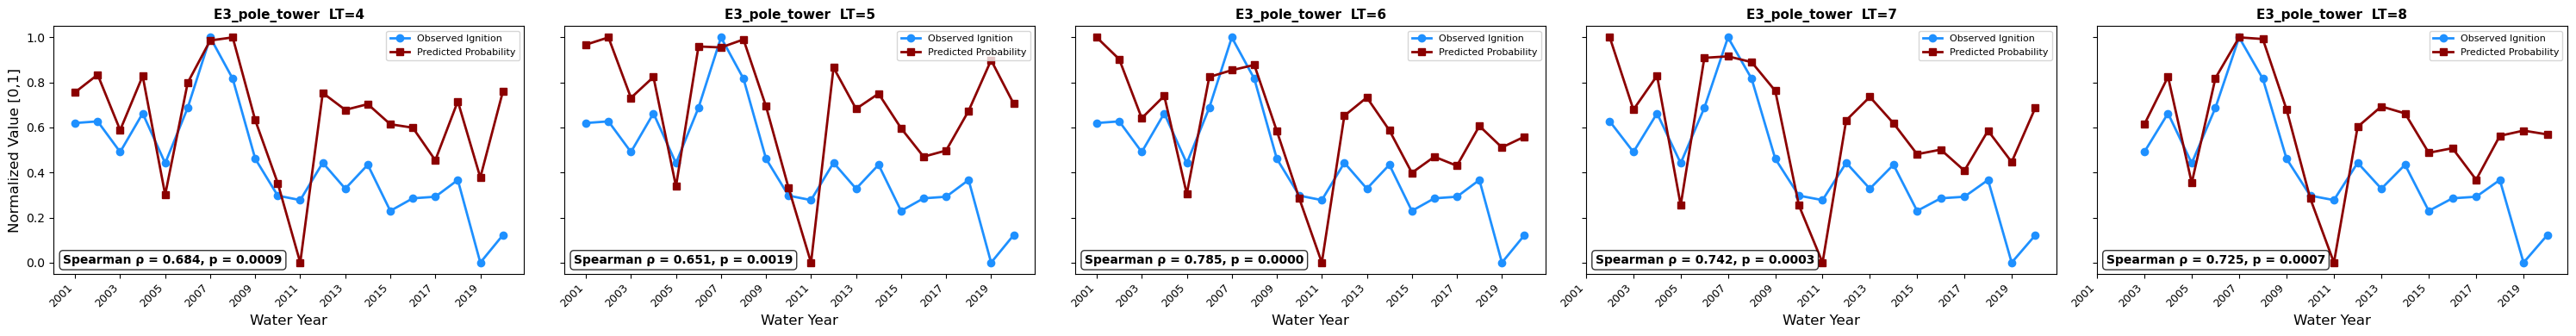

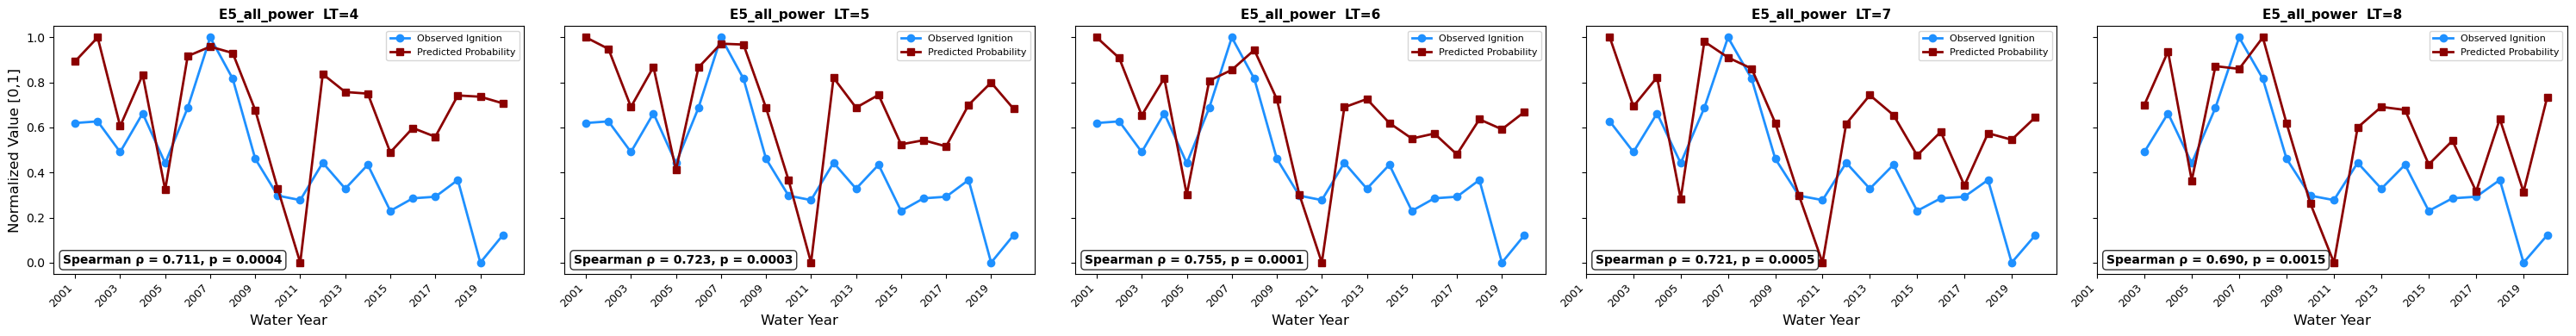

In [17]:
plot_experiments = ["E3_pole_tower", "E5_all_power"]

for exp_name in plot_experiments:
    runs = [m for m in all_metrics
            if m["experiment"] == exp_name]

    fig, axes = plt.subplots(1, len(TRAIN_LENGTHS),
                             figsize=(6 * len(TRAIN_LENGTHS), 4),
                             sharey=True)

    for ax, run in zip(axes, runs):
        adf = run["annual_df"]
        lt  = run["len_train"]
        rho = run["spearman_annual_rho"]
        p   = run["spearman_annual_p"]

        ax.plot(adf["water_year"], adf["fire_norm"],
                color="dodgerblue", linewidth=2, marker="o",
                markersize=6, label="Observed Ignition")
        ax.plot(adf["water_year"], adf["pred_norm"],
                color="darkred", linewidth=2, marker="s",
                markersize=6, label="Predicted Probability")

        ax.set_xlabel("Water Year", fontsize=12)
        ax.set_xticks(np.arange(2001, 2021, 2))
        ax.set_xticklabels(np.arange(2001, 2021, 2), rotation=45,
                           ha="right", fontsize=9)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(False)
        ax.set_title(f"{exp_name}  LT={lt}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=8, loc="upper right")
        ax.text(0.02, 0.08,
                f"Spearman ρ = {rho:.3f}, p = {p:.4f}",
                transform=ax.transAxes, fontsize=10, fontweight="bold",
                verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.8))

    axes[0].set_ylabel("Normalized Value [0,1]", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,
                f"annual_trend_{exp_name}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

## 9. Spearman ρ — Deseasonalised Anomaly Correlation

Spearman rank correlation between observed ignition anomalies and predicted
probability anomalies after removing the climatological seasonal cycle
(mean per calendar month, 2001–2020). Higher ρ indicates the model captures
inter-annual variability beyond the seasonal mean.

In [10]:
spear = summary.pivot(index="experiment", columns="len_train",
                      values="spearman_rho")
spear.columns = [f"LT={c}" for c in spear.columns]
print("Spearman rho (deseasonalised anomalies, 2001-2020)")
print("=" * 60)
print(spear.round(4).to_string())

spear_p = summary.pivot(index="experiment", columns="len_train",
                        values="spearman_p")
spear_p.columns = [f"LT={c}" for c in spear_p.columns]
print("\np-values")
print("-" * 60)
print(spear_p.to_string(float_format="%.2e"))

Spearman rho (deseasonalised anomalies, 2001-2020)
                            LT=4    LT=5    LT=6    LT=7    LT=8
experiment                                                      
E1_line                   0.6173  0.6840  0.6820  0.6663  0.6751
E2_line_minor             0.6314  0.6876  0.6824  0.6748  0.6965
E3_pole_tower             0.6083  0.6618  0.7079  0.6696  0.7069
E4_line_minor_pole_tower  0.6031  0.6496  0.6715  0.6722  0.6856
E5_all_power              0.6036  0.6494  0.6673  0.6830  0.6762

p-values
------------------------------------------------------------
                             LT=4     LT=5     LT=6     LT=7     LT=8
experiment                                                           
E1_line                  1.32e-26 1.86e-34 3.51e-34 1.24e-30 4.26e-30
E2_line_minor            4.25e-28 6.23e-35 3.06e-34 1.18e-31 1.10e-32
E3_pole_tower            1.12e-25 1.27e-31 8.24e-38 4.99e-31 5.03e-34
E4_line_minor_pole_tower 3.69e-25 3.71e-30 7.96e-33 2.46e-31 2.44e-31
E5_

## 10. Mean-Metric Heatmaps

Quick visual comparison across all 25 configurations.

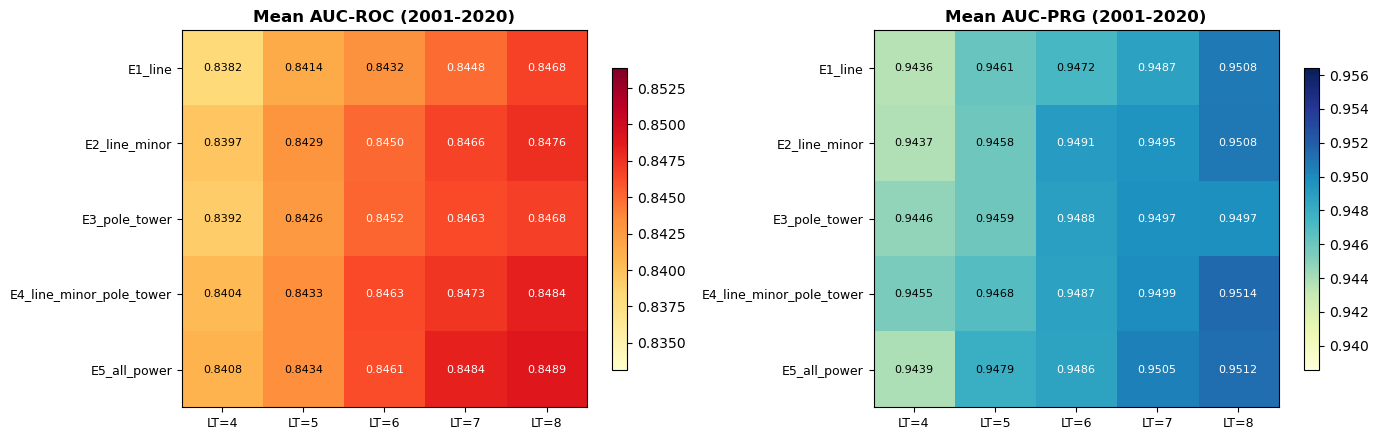

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, metric, title, cmap in [
    (ax1, "mean_roc", "Mean AUC-ROC (2001-2020)", "YlOrRd"),
    (ax2, "mean_prg", "Mean AUC-PRG (2001-2020)", "YlGnBu"),
]:
    piv = summary.pivot(index="experiment", columns="len_train", values=metric)
    im = ax.imshow(piv.values, cmap=cmap, aspect="auto",
                   vmin=piv.values.min() - 0.005,
                   vmax=piv.values.max() + 0.005)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"LT={c}" for c in piv.columns], fontsize=9)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.4f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if piv.values[i, j] > piv.values.mean()
                    else "black")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "heatmap_summary.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## 11. Save Full Per-Year Results

Long-format CSV with one row per (experiment, training length, water year)
for downstream analysis or plotting in other tools.

In [18]:
rows = []
for m in all_metrics:
    for yr, roc, prg in zip(m["predicted_years"],
                            m["yearly_roc"], m["yearly_prg"]):
        rows.append({
            "experiment":  m["experiment"],
            "len_train":   m["len_train"],
            "water_year":  yr,
            "auc_roc":     roc,
            "auc_prg":     prg,
        })
full = pd.DataFrame(rows)
out_path = os.path.join(RESULTS_DIR, "yearly_metrics_all_experiments.csv")
full.to_csv(out_path, index=False)
print(f"Saved {len(full)} rows -> {out_path}")
print(f"\nDone.  Total configurations: {len(all_metrics)}")

Saved 485 rows -> E:\zcao\Ignition - ML Modeling\Results\yearly_metrics_all_experiments.csv

Done.  Total configurations: 25
